In [1]:
import os
import sys
import numpy as np

In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# add project root to path
sys.path.append("..")

from main import get_simdata2

In [3]:
nodeLoads = np.logspace(2, 4, 20)   # 100 → 10000 nodes
demodulators = [10, 100, 1000]

In [4]:
baseline = {}

for d in demodulators:
    
    decoded = []
    
    print("\nTesting baseline with", d, "demodulators")

    for n in nodeLoads:
        
        x = get_simdata2(n, d, False, False)
        
        decoded.append(x[3])  # decoded_hdr_pld
        
    baseline[d] = decoded


Testing baseline with 10 demodulators
Nodes: 100
Tracked TXs: 10
Decoded hdr+pld: 7
Collided hdr+pld: 0
Decoded bytes: 140
Header drops: 0
------
Nodes: 127
Tracked TXs: 10
Decoded hdr+pld: 8
Collided hdr+pld: 0
Decoded bytes: 160
Header drops: 0
------
Nodes: 162
Tracked TXs: 10
Decoded hdr+pld: 6
Collided hdr+pld: 0
Decoded bytes: 120
Header drops: 0
------
Nodes: 206
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 4
Decoded bytes: 20
Header drops: 0
------
Nodes: 263
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 3
Decoded bytes: 20
Header drops: 0
------
Nodes: 335
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 5
Decoded bytes: 20
Header drops: 0
------
Nodes: 428
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 8
Decoded bytes: 20
Header drops: 0
------
Nodes: 545
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 9
Decoded bytes: 0
Header drops: 0
------
Nodes: 695
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 9
Decoded bytes: 0
Header drops: 0
----

In [5]:
early = {}

for d in demodulators:
    
    decoded = []
    
    print("\nTesting early decode with", d, "demodulators")

    for n in nodeLoads:
        
        x = get_simdata2(n, d, True, True)
        
        decoded.append(x[3])
        
    early[d] = decoded


Testing early decode with 10 demodulators
Nodes: 100
Tracked TXs: 10
Decoded hdr+pld: 7
Collided hdr+pld: 0
Decoded bytes: 140
Header drops: 0
------
Nodes: 127
Tracked TXs: 10
Decoded hdr+pld: 8
Collided hdr+pld: 0
Decoded bytes: 160
Header drops: 0
------
Nodes: 162
Tracked TXs: 10
Decoded hdr+pld: 6
Collided hdr+pld: 0
Decoded bytes: 120
Header drops: 0
------
Nodes: 206
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 4
Decoded bytes: 20
Header drops: 0
------
Nodes: 263
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 3
Decoded bytes: 20
Header drops: 0
------
Nodes: 335
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 5
Decoded bytes: 20
Header drops: 0
------
Nodes: 428
Tracked TXs: 10
Decoded hdr+pld: 1
Collided hdr+pld: 8
Decoded bytes: 20
Header drops: 0
------
Nodes: 545
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 9
Decoded bytes: 0
Header drops: 0
------
Nodes: 695
Tracked TXs: 10
Decoded hdr+pld: 0
Collided hdr+pld: 9
Decoded bytes: 0
Header drops: 0


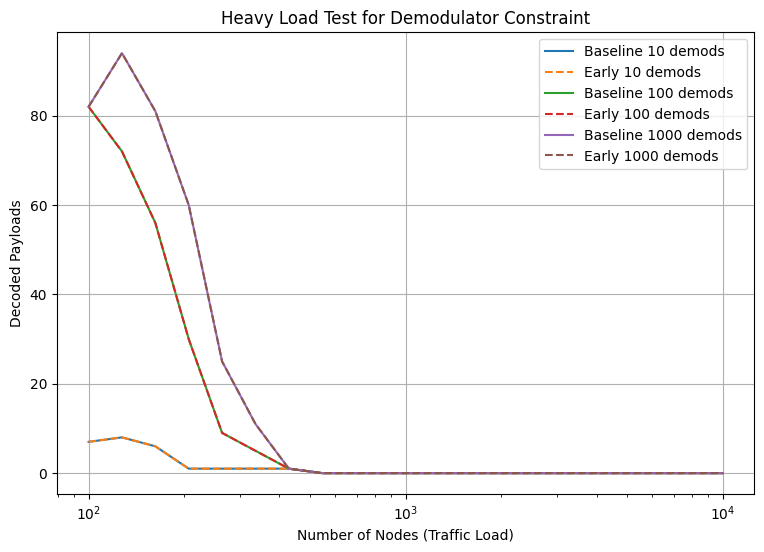

In [6]:
plt.figure(figsize=(9,6))

for d in demodulators:
    
    plt.plot(nodeLoads, baseline[d], label=f"Baseline {d} demods")
    plt.plot(nodeLoads, early[d], linestyle="--", label=f"Early {d} demods")

plt.xscale("log")

plt.xlabel("Number of Nodes (Traffic Load)")
plt.ylabel("Decoded Payloads")
plt.title("Heavy Load Test for Demodulator Constraint")

plt.legend()
plt.grid(True)

plt.show()